# HW12 – Временные ряды: temporal split, baseline-модели и GRU-прогноз

В этом ноутбуке реализованы:
- Загрузка и анализ часового временного ряда (`S12-hw-dataset.csv`)
- Корректный **temporal split** на train / validation / test
- Построение лаговых, rolling- и календарных признаков
- Эксперименты **B1** (naive-last), **B2** (moving-average), **B3** (ridge-lag-features), **R1** (gru-forecast)
- Выбор лучшего подхода по validation и финальная оценка на test

## 1. Импорты, seed и устройство

In [1]:
import json
import csv
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Device: cpu
PyTorch version: 2.8.0
pandas version: 2.3.3
numpy version: 2.0.2


## 2. Подготовка артефактов

In [2]:
artifacts_dir = Path("artifacts")
figures_dir = artifacts_dir / "figures"
artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

RUNS_CSV = artifacts_dir / "runs.csv"
BEST_GRU_PATH = artifacts_dir / "best_gru.pt"
BEST_GRU_CONFIG_PATH = artifacts_dir / "best_gru_config.json"

# Удаляем старый runs.csv если есть
if RUNS_CSV.exists():
    RUNS_CSV.unlink()

print(f"Artifacts will be saved to: {artifacts_dir.absolute()}")

Artifacts will be saved to: /Users/v.razon/Desktop/вуз/ml/mirea-aie-project/homeworks/HW12/artifacts


## 3. Данные и первичный анализ

In [3]:
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Число наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Частота: {pd.infer_freq(df['date'])}")
print(f"\nПропуски по колонкам:")
print(df.isnull().sum())
print(f"\nОписательная статистика:")
print(df["target"].describe())

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00
Частота: h

Пропуски по колонкам:
date      0
target    0
dtype: int64

Описательная статистика:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


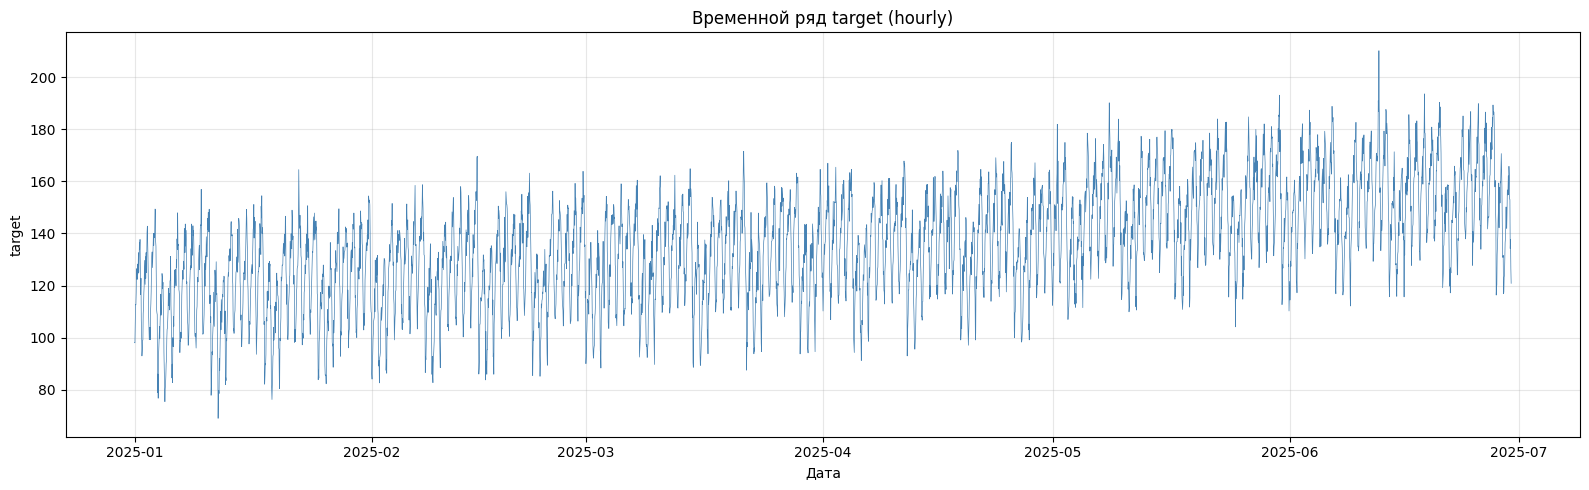

Комментарий: ряд имеет слабый положительный тренд (среднее растёт к лету).
Видна выраженная суточная сезонность (24-часовой цикл).
Явных выбросов не наблюдается, пропусков нет.
Ряд выглядит нестационарным из-за тренда.


In [4]:
# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["target"], linewidth=0.5, color="steelblue")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.set_title("Временной ряд target (hourly)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Комментарий: ряд имеет слабый положительный тренд (среднее растёт к лету).")
print("Видна выраженная суточная сезонность (24-часовой цикл).")
print("Явных выбросов не наблюдается, пропусков нет.")
print("Ряд выглядит нестационарным из-за тренда.")

## 4. Корректный temporal split

In [5]:
n = len(df)
train_end = int(n * 0.7)   # 70% train
val_end = int(n * 0.85)    # 15% validation
                            # 15% test

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print(f"Train: {len(df_train)} ({df_train['date'].min()} — {df_train['date'].max()})")
print(f"Val:   {len(df_val)} ({df_val['date'].min()} — {df_val['date'].max()})")
print(f"Test:  {len(df_test)} ({df_test['date'].min()} — {df_test['date'].max()})")
print(f"\nСоотношение: {len(df_train)/n:.0%} / {len(df_val)/n:.0%} / {len(df_test)/n:.0%}")

Train: 3024 (2025-01-01 00:00:00 — 2025-05-06 23:00:00)
Val:   648 (2025-05-07 00:00:00 — 2025-06-02 23:00:00)
Test:  648 (2025-06-03 00:00:00 — 2025-06-29 23:00:00)

Соотношение: 70% / 15% / 15%


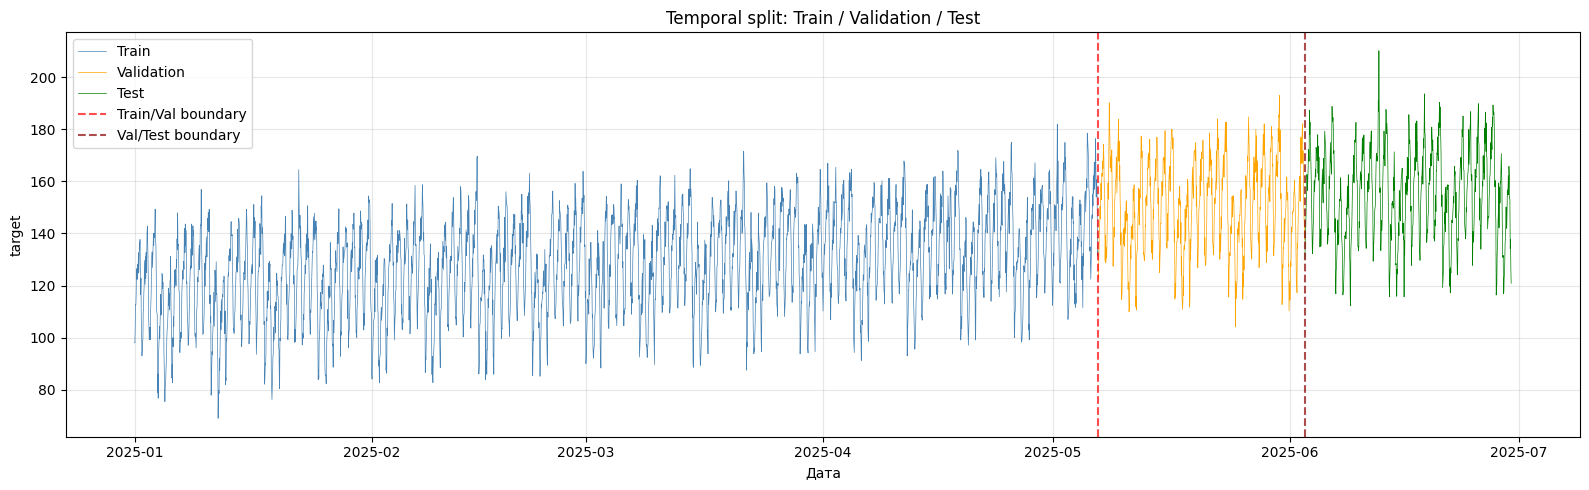

Saved: artifacts/figures/series_split.png


In [6]:
# Визуализация split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_train["date"], df_train["target"], label="Train", linewidth=0.5, color="steelblue")
ax.plot(df_val["date"], df_val["target"], label="Validation", linewidth=0.5, color="orange")
ax.plot(df_test["date"], df_test["target"], label="Test", linewidth=0.5, color="green")
ax.axvline(df_val["date"].iloc[0], color="red", linestyle="--", alpha=0.7, label="Train/Val boundary")
ax.axvline(df_test["date"].iloc[0], color="darkred", linestyle="--", alpha=0.7, label="Val/Test boundary")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.set_title("Temporal split: Train / Validation / Test")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / 'series_split.png'}")

### Почему random split некорректен

Во временных рядах наблюдения автокоррелированы: значение в момент *t* зависит от значений в моменты *t-1*, *t-2*, и т.д. 
Если перемешать данные случайным образом, то в train попадут наблюдения из **будущего** относительно validation/test. 
Это создаёт **утечку данных** (data leakage): модель фактически «видит» будущее при обучении, 
что приводит к завышенным метрикам на валидации и неадекватным оценкам качества на реальных данных.

Корректный подход — **temporal split**: train идёт до валидации по времени, валидация — до теста.

## 5. Признаки для baseline-моделей

In [7]:
def build_features(data):
    """Строит лаговые, rolling- и календарные признаки."""
    out = data.copy()
    # Лаговые признаки
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)       # 7 часов назад
    out["lag_14"] = out["target"].shift(14)     # 14 часов назад
    out["lag_24"] = out["target"].shift(24)     # сутки назад
    out["lag_168"] = out["target"].shift(168)   # неделя назад (24*7)
    
    # Rolling-признаки (скользящее среднее и std по окну 7)
    out["rolling_mean_7"] = out["target"].shift(1).rolling(7).mean()
    out["rolling_std_7"] = out["target"].shift(1).rolling(7).std()
    out["rolling_mean_24"] = out["target"].shift(1).rolling(24).mean()
    
    # Календарные признаки
    out["hour"] = out["date"].dt.hour
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["is_weekend"] = (out["dayofweek"] >= 5).astype(int)
    
    return out

# Строим признаки на всём датасете (лаги используют только прошлое)
df_feat = build_features(df)

# Снова делим по тем же индексам
df_train_f = df_feat.iloc[:train_end].copy()
df_val_f = df_feat.iloc[train_end:val_end].copy()
df_test_f = df_feat.iloc[val_end:].copy()

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_24", "lag_168",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_24",
    "hour", "dayofweek", "month", "is_weekend"
]

# Удаляем строки с NaN в train (первые 168 строк из-за lag_168)
df_train_f = df_train_f.dropna(subset=FEATURE_COLS)

print(f"Train (после удаления NaN от лагов): {len(df_train_f)}")
print(f"Val: {len(df_val_f)}, NaN в val: {df_val_f[FEATURE_COLS].isnull().sum().sum()}")
print(f"Test: {len(df_test_f)}, NaN в test: {df_test_f[FEATURE_COLS].isnull().sum().sum()}")
print(f"\nПризнаки: {FEATURE_COLS}")

Train (после удаления NaN от лагов): 2856
Val: 648, NaN в val: 0
Test: 648, NaN в test: 0

Признаки: ['lag_1', 'lag_7', 'lag_14', 'lag_24', 'lag_168', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_24', 'hour', 'dayofweek', 'month', 'is_weekend']


In [8]:
# Масштабирование: fit только на train
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(df_train_f[FEATURE_COLS].values)
y_train = df_train_f["target"].values

X_val = scaler_X.transform(df_val_f[FEATURE_COLS].values)
y_val = df_val_f["target"].values

X_test = scaler_X.transform(df_test_f[FEATURE_COLS].values)
y_test = df_test_f["target"].values

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (2856, 12), X_val: (648, 12), X_test: (648, 12)


## 6. Метрики

In [9]:
def compute_metrics(y_true, y_pred):
    """Вычисляет MAE, RMSE, MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}


def log_to_csv(experiment_id, task, dataset, seed, split_summary,
               window_size, horizon, model_summary, features_summary,
               scaler, optimizer, lr, epochs_trained,
               best_val_mae, best_val_rmse, best_val_mape,
               test_mae, test_rmse, test_mape, notes=""):
    """Записывает результаты эксперимента в runs.csv."""
    is_new = not RUNS_CSV.exists()
    with RUNS_CSV.open("a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        if is_new:
            writer.writerow([
                "experiment_id", "task", "dataset", "seed", "split_summary",
                "window_size", "horizon", "model_summary", "features_summary",
                "scaler", "optimizer", "lr", "epochs_trained",
                "best_val_mae", "best_val_rmse", "best_val_mape",
                "test_mae", "test_rmse", "test_mape", "notes"
            ])
        writer.writerow([
            experiment_id, task, dataset, seed, split_summary,
            window_size, horizon, model_summary, features_summary,
            scaler, optimizer, lr, epochs_trained,
            f"{best_val_mae:.4f}" if best_val_mae is not None else "",
            f"{best_val_rmse:.4f}" if best_val_rmse is not None else "",
            f"{best_val_mape:.4f}" if best_val_mape is not None else "",
            f"{test_mae:.4f}" if test_mae is not None else "",
            f"{test_rmse:.4f}" if test_rmse is not None else "",
            f"{test_mape:.4f}" if test_mape is not None else "",
            notes
        ])


SPLIT_SUMMARY = f"70/15/15 temporal ({len(df_train)}/{len(df_val)}/{len(df_test)})"
DATASET_NAME = "S12-hw-dataset.csv"

print("Metric and logging functions defined.")

Metric and logging functions defined.


## 7. Эксперимент B1: Naive-Last

In [10]:
print("=" * 60)
print("B1: Naive-Last baseline")
print("=" * 60)

# Прогноз = предыдущее значение (lag_1)
pred_val_b1 = df_val_f["lag_1"].values
pred_test_b1 = df_test_f["lag_1"].values

metrics_val_b1 = compute_metrics(y_val, pred_val_b1)
metrics_test_b1 = compute_metrics(y_test, pred_test_b1)

print(f"Validation — MAE: {metrics_val_b1['mae']:.4f}, RMSE: {metrics_val_b1['rmse']:.4f}, MAPE: {metrics_val_b1['mape']:.2f}%")

log_to_csv(
    experiment_id="B1", task="forecasting", dataset=DATASET_NAME, seed=SEED,
    split_summary=SPLIT_SUMMARY, window_size="", horizon=1,
    model_summary="naive-last (y_pred = y_{t-1})",
    features_summary="lag_1", scaler="none", optimizer="", lr="",
    epochs_trained="",
    best_val_mae=metrics_val_b1["mae"], best_val_rmse=metrics_val_b1["rmse"],
    best_val_mape=metrics_val_b1["mape"],
    test_mae=metrics_test_b1["mae"], test_rmse=metrics_test_b1["rmse"],
    test_mape=metrics_test_b1["mape"],
    notes="Baseline: predict previous value"
)

B1: Naive-Last baseline
Validation — MAE: 6.4448, RMSE: 8.2010, MAPE: 4.40%


## 8. Эксперимент B2: Moving Average

In [11]:
print("=" * 60)
print("B2: Moving Average baseline (window=24)")
print("=" * 60)

# Скользящее среднее по 24 предыдущим значениям
pred_val_b2 = df_val_f["rolling_mean_24"].values
pred_test_b2 = df_test_f["rolling_mean_24"].values

metrics_val_b2 = compute_metrics(y_val, pred_val_b2)
metrics_test_b2 = compute_metrics(y_test, pred_test_b2)

print(f"Validation — MAE: {metrics_val_b2['mae']:.4f}, RMSE: {metrics_val_b2['rmse']:.4f}, MAPE: {metrics_val_b2['mape']:.2f}%")

log_to_csv(
    experiment_id="B2", task="forecasting", dataset=DATASET_NAME, seed=SEED,
    split_summary=SPLIT_SUMMARY, window_size=24, horizon=1,
    model_summary="moving-average (window=24h)",
    features_summary="rolling_mean_24", scaler="none", optimizer="", lr="",
    epochs_trained="",
    best_val_mae=metrics_val_b2["mae"], best_val_rmse=metrics_val_b2["rmse"],
    best_val_mape=metrics_val_b2["mape"],
    test_mae=metrics_test_b2["mae"], test_rmse=metrics_test_b2["rmse"],
    test_mape=metrics_test_b2["mape"],
    notes="Baseline: 24-hour rolling mean of past values"
)

B2: Moving Average baseline (window=24)
Validation — MAE: 13.3980, RMSE: 16.1699, MAPE: 9.20%


## 9. Эксперимент B3: Ridge на лаговых признаках

In [12]:
print("=" * 60)
print("B3: Ridge regression на лаговых, rolling- и календарных признаках")
print("=" * 60)

ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train, y_train)

pred_val_b3 = ridge.predict(X_val)
pred_test_b3 = ridge.predict(X_test)

metrics_val_b3 = compute_metrics(y_val, pred_val_b3)
metrics_test_b3 = compute_metrics(y_test, pred_test_b3)

print(f"Validation — MAE: {metrics_val_b3['mae']:.4f}, RMSE: {metrics_val_b3['rmse']:.4f}, MAPE: {metrics_val_b3['mape']:.2f}%")

log_to_csv(
    experiment_id="B3", task="forecasting", dataset=DATASET_NAME, seed=SEED,
    split_summary=SPLIT_SUMMARY, window_size="", horizon=1,
    model_summary="Ridge(alpha=1.0) on lag+rolling+calendar features",
    features_summary=", ".join(FEATURE_COLS), scaler="StandardScaler (fit on train)",
    optimizer="closed-form", lr="", epochs_trained="",
    best_val_mae=metrics_val_b3["mae"], best_val_rmse=metrics_val_b3["rmse"],
    best_val_mape=metrics_val_b3["mape"],
    test_mae=metrics_test_b3["mae"], test_rmse=metrics_test_b3["rmse"],
    test_mape=metrics_test_b3["mape"],
    notes="Ridge on 12 features: lags, rolling stats, calendar"
)

B3: Ridge regression на лаговых, rolling- и календарных признаках
Validation — MAE: 4.8944, RMSE: 6.2384, MAPE: 3.26%


## 10. Оконное представление и GRU-модель (R1)

In [13]:
# Параметры GRU
WINDOW_SIZE = 48
HIDDEN_SIZE = 64
NUM_LAYERS = 1
BATCH_SIZE = 64
LR = 1e-3
MAX_EPOCHS = 50
PATIENCE = 7  # early stopping

print(f"Window size: {WINDOW_SIZE}")
print(f"Hidden size: {HIDDEN_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LR}")
print(f"Max epochs: {MAX_EPOCHS}")

Window size: 48
Hidden size: 64
Batch size: 64
Learning rate: 0.001
Max epochs: 50


In [14]:
# Масштабирование таргета для GRU (fit только на train)
target_scaler = StandardScaler()
target_scaler.fit(df_train["target"].values.reshape(-1, 1))

all_target_scaled = target_scaler.transform(df["target"].values.reshape(-1, 1)).flatten()


class TimeSeriesDataset(Dataset):
    """Dataset для оконного представления: (window_size,) -> (1,)"""
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]
        return torch.FloatTensor(x).unsqueeze(-1), torch.FloatTensor([y])


# Создаём датасеты: train использует только train-часть,
# val начинает окна с (train_end - WINDOW_SIZE), чтобы первое окно целиком из train
train_series = all_target_scaled[:train_end]
val_series = all_target_scaled[train_end - WINDOW_SIZE : val_end]
test_series = all_target_scaled[val_end - WINDOW_SIZE :]

train_ds = TimeSeriesDataset(train_series, WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_series, WINDOW_SIZE)
test_ds = TimeSeriesDataset(test_series, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train sequences: {len(train_ds)}")
print(f"Val sequences: {len(val_ds)}")
print(f"Test sequences: {len(test_ds)}")

# Sanity check
x_sample, y_sample = train_ds[0]
print(f"\nSample x shape: {x_sample.shape}, y shape: {y_sample.shape}")

Train sequences: 2976
Val sequences: 648
Test sequences: 648

Sample x shape: torch.Size([48, 1]), y shape: torch.Size([1])


In [15]:
class GRUForecaster(nn.Module):
    """GRU для прогноза следующего значения временного ряда."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.gru(x)        # out: (batch, seq_len, hidden)
        out = out[:, -1, :]          # берём последний шаг: (batch, hidden)
        return self.fc(out)          # (batch, 1)


model_gru = GRUForecaster(
    input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS
).to(device)

n_params = sum(p.numel() for p in model_gru.parameters())
print(f"GRU model parameters: {n_params:,}")
print(model_gru)

GRU model parameters: 12,929
GRUForecaster(
  (gru): GRU(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [16]:
print("=" * 60)
print("R1: GRU Forecast")
print("=" * 60)

torch.manual_seed(SEED)
np.random.seed(SEED)

model_gru = GRUForecaster(
    input_size=1, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "val_mae": []}
best_val_mae = float("inf")
best_state = None
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    model_gru.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model_gru(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    train_loss = np.mean(train_losses)

    # Validation
    model_gru.eval()
    val_preds_scaled = []
    val_targets_scaled = []
    val_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model_gru(xb)
            val_losses.append(criterion(pred, yb).item())
            val_preds_scaled.append(pred.cpu().numpy())
            val_targets_scaled.append(yb.cpu().numpy())

    val_loss = np.mean(val_losses)
    val_preds_scaled = np.concatenate(val_preds_scaled)
    val_targets_scaled = np.concatenate(val_targets_scaled)

    # Обратное масштабирование для MAE в исходных единицах
    val_preds_orig = target_scaler.inverse_transform(val_preds_scaled).flatten()
    val_targets_orig = target_scaler.inverse_transform(val_targets_scaled).flatten()
    val_mae = mean_absolute_error(val_targets_orig, val_preds_orig)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_state = {k: v.cpu().clone() for k, v in model_gru.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 5 == 0 or epoch == 1:
        print(f"[R1] Epoch {epoch}/{MAX_EPOCHS} | "
              f"train_loss={train_loss:.6f}, val_loss={val_loss:.6f} | "
              f"val_MAE={val_mae:.4f}")

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (patience={PATIENCE})")
        break

epochs_trained = epoch
print(f"\nBest validation MAE: {best_val_mae:.4f} (original scale)")

# Загружаем лучшее состояние
model_gru.load_state_dict(best_state)
model_gru = model_gru.to(device)

R1: GRU Forecast


[R1] Epoch 1/50 | train_loss=0.716184, val_loss=0.560513 | val_MAE=11.9721


[R1] Epoch 5/50 | train_loss=0.155074, val_loss=0.211722 | val_MAE=6.9815


[R1] Epoch 10/50 | train_loss=0.113650, val_loss=0.154414 | val_MAE=5.6418


[R1] Epoch 15/50 | train_loss=0.101090, val_loss=0.160732 | val_MAE=5.7382


[R1] Epoch 20/50 | train_loss=0.096642, val_loss=0.161771 | val_MAE=5.6520


[R1] Epoch 25/50 | train_loss=0.095548, val_loss=0.136647 | val_MAE=5.2806
Early stopping at epoch 25 (patience=7)

Best validation MAE: 5.0569 (original scale)


In [17]:
# Оценка GRU на validation и test
def predict_gru(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb)
            preds.append(pred.cpu().numpy())
            targets.append(yb.numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    # Обратное масштабирование
    preds_orig = target_scaler.inverse_transform(preds).flatten()
    targets_orig = target_scaler.inverse_transform(targets).flatten()
    return preds_orig, targets_orig


pred_val_r1, y_val_r1 = predict_gru(model_gru, val_loader)
pred_test_r1, y_test_r1 = predict_gru(model_gru, test_loader)

metrics_val_r1 = compute_metrics(y_val_r1, pred_val_r1)
metrics_test_r1 = compute_metrics(y_test_r1, pred_test_r1)

print(f"R1 Validation — MAE: {metrics_val_r1['mae']:.4f}, RMSE: {metrics_val_r1['rmse']:.4f}, MAPE: {metrics_val_r1['mape']:.2f}%")

# Сохраняем модель и конфиг
torch.save(best_state, BEST_GRU_PATH)

gru_config = {
    "experiment_id": "R1",
    "architecture": "GRU",
    "input_size": 1,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "max_epochs": MAX_EPOCHS,
    "epochs_trained": epochs_trained,
    "patience": PATIENCE,
    "seed": SEED,
    "scaler": "StandardScaler (fit on train target)",
    "optimizer": "Adam",
    "criterion": "MSELoss",
    "best_val_mae": float(f"{metrics_val_r1['mae']:.4f}"),
    "best_val_rmse": float(f"{metrics_val_r1['rmse']:.4f}"),
    "best_val_mape": float(f"{metrics_val_r1['mape']:.4f}")
}
BEST_GRU_CONFIG_PATH.write_text(
    json.dumps(gru_config, indent=2, ensure_ascii=False), encoding="utf-8"
)

log_to_csv(
    experiment_id="R1", task="forecasting", dataset=DATASET_NAME, seed=SEED,
    split_summary=SPLIT_SUMMARY, window_size=WINDOW_SIZE, horizon=1,
    model_summary=f"GRU(hidden={HIDDEN_SIZE}, layers={NUM_LAYERS})",
    features_summary="target (scaled)", scaler="StandardScaler (fit on train)",
    optimizer="Adam", lr=LR, epochs_trained=epochs_trained,
    best_val_mae=metrics_val_r1["mae"], best_val_rmse=metrics_val_r1["rmse"],
    best_val_mape=metrics_val_r1["mape"],
    test_mae=metrics_test_r1["mae"], test_rmse=metrics_test_r1["rmse"],
    test_mape=metrics_test_r1["mape"],
    notes=f"GRU with early stopping (patience={PATIENCE})"
)

print(f"\nSaved: {BEST_GRU_PATH}")
print(f"Saved: {BEST_GRU_CONFIG_PATH}")

R1 Validation — MAE: 5.0569, RMSE: 6.6016, MAPE: 3.42%

Saved: artifacts/best_gru.pt
Saved: artifacts/best_gru_config.json


## 11. Визуализация результатов

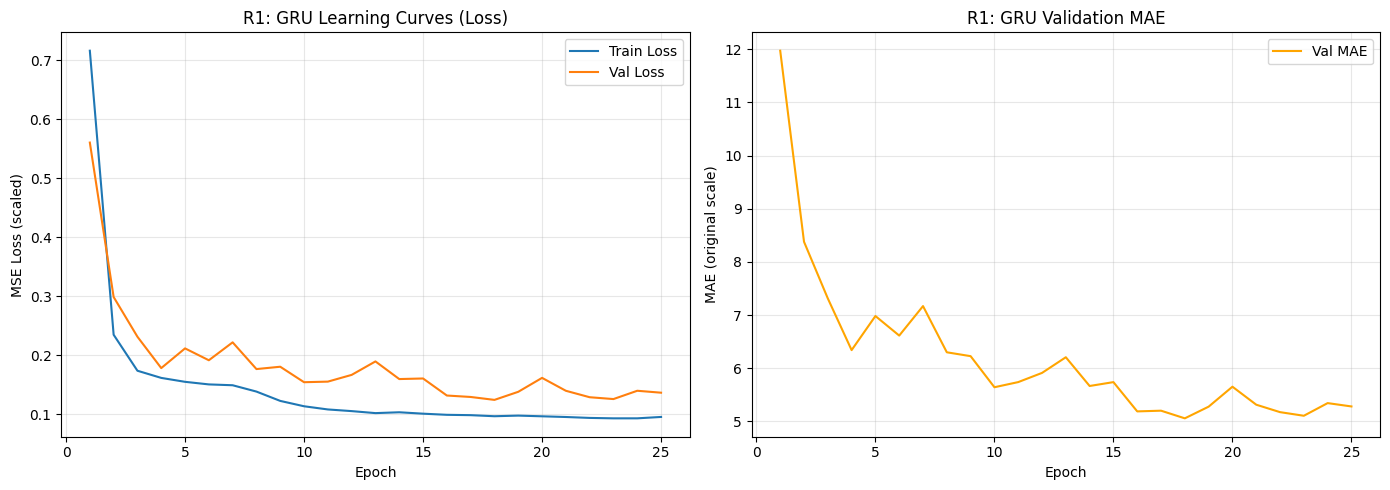

Saved: artifacts/figures/gru_learning_curves.png


In [18]:
# Кривые обучения GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (scaled)")
axes[0].set_title("R1: GRU Learning Curves (Loss)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["val_mae"], label="Val MAE", color="orange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE (original scale)")
axes[1].set_title("R1: GRU Validation MAE")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / 'gru_learning_curves.png'}")

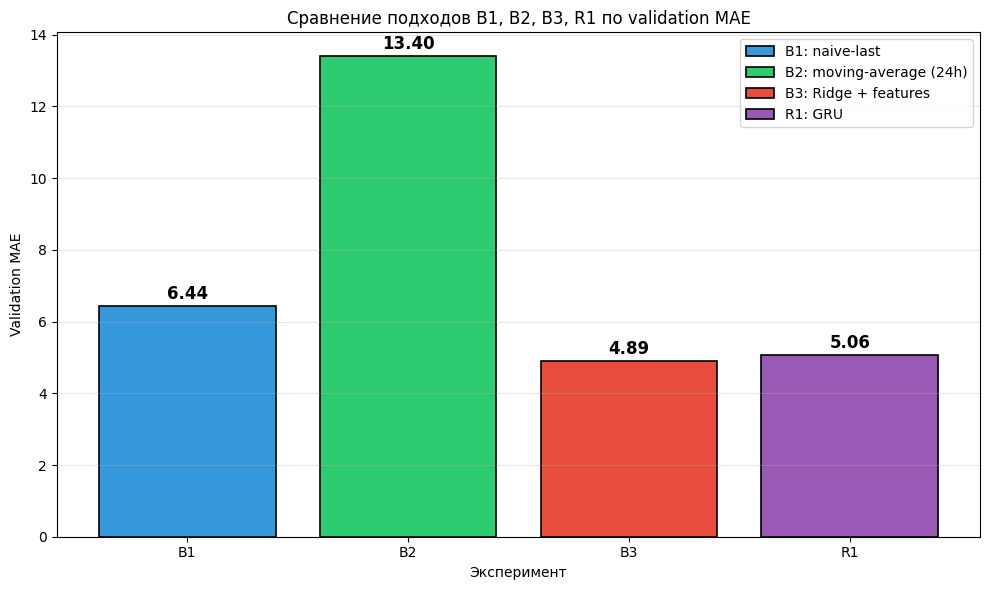

Saved: artifacts/figures/baselines_compare.png


In [19]:
# Сравнение подходов по val MAE
experiments = ["B1", "B2", "B3", "R1"]
val_maes = [
    metrics_val_b1["mae"], metrics_val_b2["mae"],
    metrics_val_b3["mae"], metrics_val_r1["mae"]
]
colors = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(experiments, val_maes, color=colors, edgecolor="black", linewidth=1.2)

for bar, v in zip(bars, val_maes):
    ax.annotate(f"{v:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Эксперимент")
ax.set_ylabel("Validation MAE")
ax.set_title("Сравнение подходов B1, B2, B3, R1 по validation MAE")
ax.grid(axis="y", alpha=0.3)

labels = [
    "B1: naive-last",
    "B2: moving-average (24h)",
    "B3: Ridge + features",
    "R1: GRU"
]
ax.legend(bars, labels, loc="upper right")

plt.tight_layout()
plt.savefig(figures_dir / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / 'baselines_compare.png'}")

In [20]:
# Выбор лучшей модели по validation MAE
all_val_results = {
    "B1": metrics_val_b1,
    "B2": metrics_val_b2,
    "B3": metrics_val_b3,
    "R1": metrics_val_r1
}

best_exp = min(all_val_results, key=lambda k: all_val_results[k]["mae"])
print(f"Лучший подход по val MAE: {best_exp} (MAE = {all_val_results[best_exp]['mae']:.4f})")

# Финальная оценка лучшего подхода на test
all_test_results = {
    "B1": metrics_test_b1,
    "B2": metrics_test_b2,
    "B3": metrics_test_b3,
    "R1": metrics_test_r1
}

best_test = all_test_results[best_exp]
print(f"\nФинальная оценка {best_exp} на test:")
print(f"  MAE:  {best_test['mae']:.4f}")
print(f"  RMSE: {best_test['rmse']:.4f}")
print(f"  MAPE: {best_test['mape']:.2f}%")

Лучший подход по val MAE: B3 (MAE = 4.8944)

Финальная оценка B3 на test:
  MAE:  4.4817
  RMSE: 5.7389
  MAPE: 2.88%


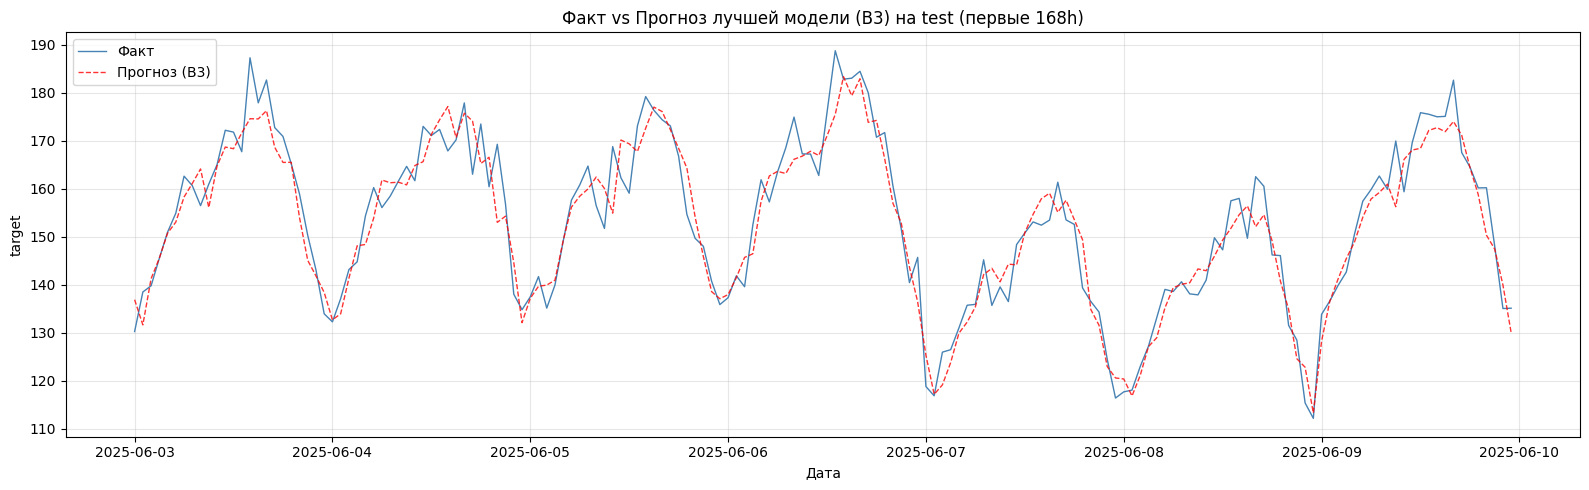

Saved: artifacts/figures/best_forecast_test.png


In [21]:
# График факта и прогноза лучшей модели на test
# Определяем прогноз лучшей модели
best_pred_map = {
    "B1": (pred_test_b1, y_test),
    "B2": (pred_test_b2, y_test),
    "B3": (pred_test_b3, y_test),
    "R1": (pred_test_r1, y_test_r1)
}

best_pred, best_actual = best_pred_map[best_exp]

# Даты для test
if best_exp == "R1":
    # GRU test имеет длину len(test_ds), начинается с val_end (после окна)
    test_dates = df["date"].iloc[val_end : val_end + len(best_pred)].values
else:
    test_dates = df_test_f["date"].values

# Показываем первые 7 дней (168 часов) для читаемости
show_n = min(168, len(best_pred))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates[:show_n], best_actual[:show_n], label="Факт", linewidth=1, color="steelblue")
ax.plot(test_dates[:show_n], best_pred[:show_n], label=f"Прогноз ({best_exp})",
        linewidth=1, color="red", linestyle="--", alpha=0.8)
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.set_title(f"Факт vs Прогноз лучшей модели ({best_exp}) на test (первые {show_n}h)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / "best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / 'best_forecast_test.png'}")

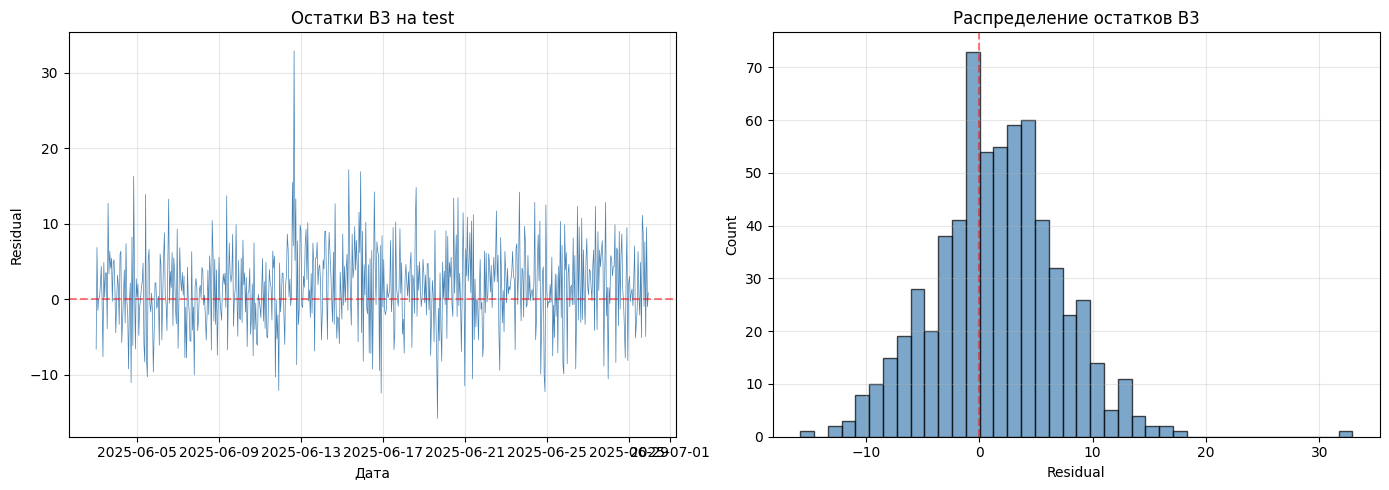

Saved: artifacts/figures/residuals_best.png


In [22]:
# Остатки лучшей модели на test
residuals = best_actual[:len(best_pred)] - best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test_dates[:len(residuals)], residuals, linewidth=0.5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"Остатки {best_exp} на test")
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals, bins=40, edgecolor="black", color="steelblue", alpha=0.7)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Распределение остатков {best_exp}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "residuals_best.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {figures_dir / 'residuals_best.png'}")

## 12. Обсуждение утечек данных

Основные источники утечек (data leakage) в задачах прогноза временных рядов:

1. **Random split** — при случайном разбиении будущие значения попадают в train, и модель обучается на информации из будущего.
2. **Rolling/lag-признаки без shift** — если rolling-статистики считаются с включением текущего значения (без `shift(1)`), происходит утечка таргета в признаки.
3. **Масштабирование на всём датасете** — если `StandardScaler` обучается на train+val+test, статистики (mean, std) содержат информацию из будущего.
4. **Заполнение пропусков глобальной статистикой** — аналогично п.3, использование среднего по всему ряду для заполнения NaN.

В данной работе мы избежали всех перечисленных утечек:
- Temporal split по хронологии
- `shift(1)` перед rolling-статистиками
- Scaler обучен только на train

## 13. Итоговая сводка

In [23]:
print("=" * 70)
print("ИТОГОВАЯ СВОДКА HW12")
print("=" * 70)

print("\nВсе эксперименты (validation):")
for exp_id in ["B1", "B2", "B3", "R1"]:
    m = all_val_results[exp_id]
    print(f"  {exp_id}: MAE={m['mae']:.4f}, RMSE={m['rmse']:.4f}, MAPE={m['mape']:.2f}%")

print(f"\nЛучший подход: {best_exp}")
print(f"\nФинальные метрики {best_exp} на test:")
print(f"  MAE:  {best_test['mae']:.4f}")
print(f"  RMSE: {best_test['rmse']:.4f}")
print(f"  MAPE: {best_test['mape']:.2f}%")

print("\n--- Артефакты ---")
print(f"  runs.csv:          {RUNS_CSV}")
print(f"  best_gru.pt:       {BEST_GRU_PATH}")
print(f"  best_gru_config:   {BEST_GRU_CONFIG_PATH}")
print(f"  Figures:           {figures_dir}/")

print("\n" + "=" * 70)
print("Ноутбук выполнен успешно!")
print("=" * 70)

ИТОГОВАЯ СВОДКА HW12

Все эксперименты (validation):
  B1: MAE=6.4448, RMSE=8.2010, MAPE=4.40%
  B2: MAE=13.3980, RMSE=16.1699, MAPE=9.20%
  B3: MAE=4.8944, RMSE=6.2384, MAPE=3.26%
  R1: MAE=5.0569, RMSE=6.6016, MAPE=3.42%

Лучший подход: B3

Финальные метрики B3 на test:
  MAE:  4.4817
  RMSE: 5.7389
  MAPE: 2.88%

--- Артефакты ---
  runs.csv:          artifacts/runs.csv
  best_gru.pt:       artifacts/best_gru.pt
  best_gru_config:   artifacts/best_gru_config.json
  Figures:           artifacts/figures/

Ноутбук выполнен успешно!


In [24]:
# Проверяем runs.csv
print("Содержимое runs.csv:")
print(pd.read_csv(RUNS_CSV).to_string())

Содержимое runs.csv:
  experiment_id         task             dataset  seed                     split_summary  window_size  horizon                                      model_summary                                                                                                           features_summary                         scaler    optimizer     lr  epochs_trained  best_val_mae  best_val_rmse  best_val_mape  test_mae  test_rmse  test_mape                                                notes
0            B1  forecasting  S12-hw-dataset.csv    42  70/15/15 temporal (3024/648/648)          NaN        1                      naive-last (y_pred = y_{t-1})                                                                                                                      lag_1                           none          NaN    NaN             NaN        6.4448         8.2010         4.3979    6.3424     8.0591     4.1485                     Baseline: predict previous value
1            B2  